In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Reading the file
Used dataset: exams.csv

In [12]:
df = pd.read_csv('exams.csv')

# 2. Main variables and task

The task is to find out what influences students' test scores

gender, race, parental level of education, lunch, test preparation course, math score, reading score, writing score

I will assume I have to analyze the total test scores (new value 'total_score'), so sum of 3 values 0-100, in total any value in range [0, 300]

In [13]:
print(df.dtypes)
df.head()

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


# 3. Histogram

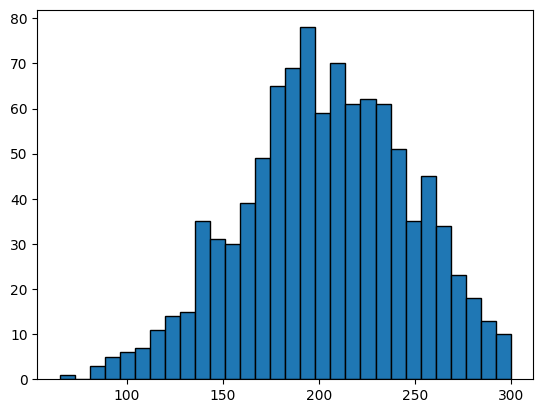

In [14]:

df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
plt.hist(df['total_score'], bins=30, edgecolor='black')
plt.show()

The distribution looks normal, with the majority at ~200. very low amount of students getting under 100 points

# 4. Main statistical values

In [15]:
df.describe()

,math score,reading score,writing score,total_score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000,203.136000
std,15.402871,14.737272,15.600985,43.542732
min,13.000000,27.000000,23.000000,65.000000
25%,56.000000,60.000000,58.000000,175.750000
50%,66.500000,70.000000,68.000000,202.000000
75%,77.000000,79.000000,79.000000,235.000000
max,100.000000,100.000000,100.000000,300.000000


# 5. Main dataframe info

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
 8   total_score                  1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


# 6. Counting None/null

In [17]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
total_score                    0
dtype: int64

There are no nulls, we don't need to replace or fill them

# 7. 3 random histograms

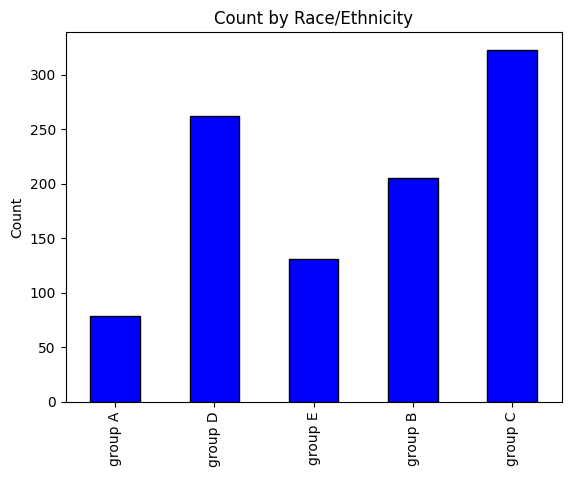

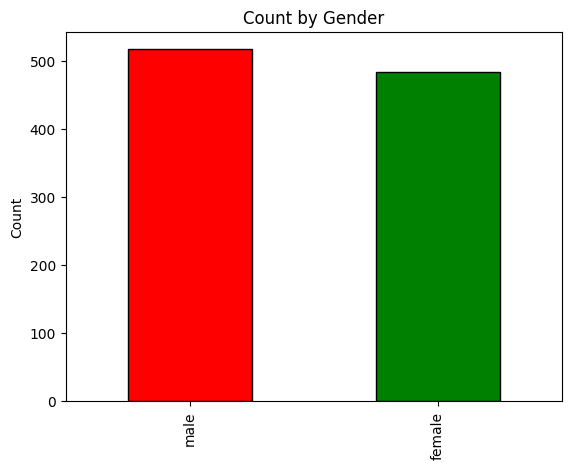

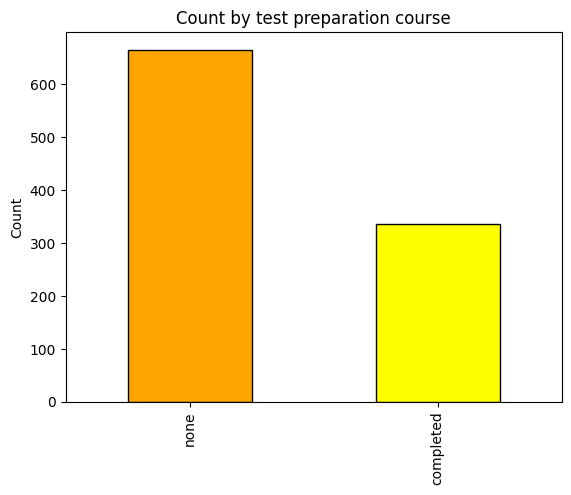

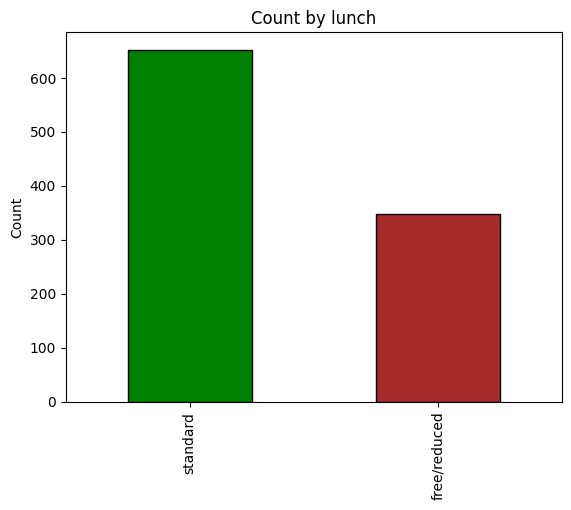

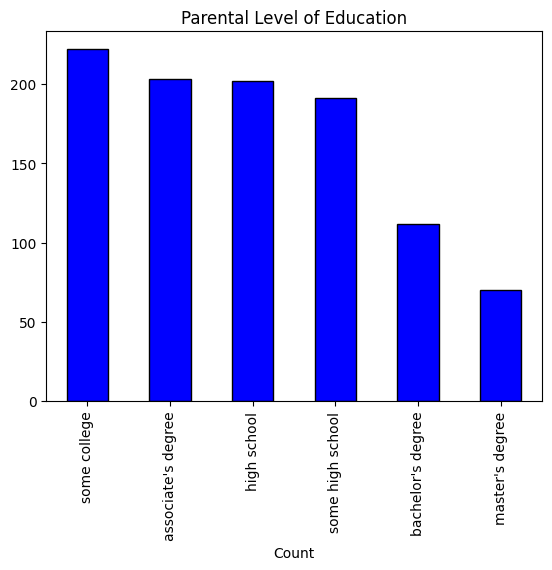

In [34]:

ethnicity_groups = df['race/ethnicity'].unique()
race_counts = df['race/ethnicity'].value_counts().reindex(ethnicity_groups)
race_counts.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Count by Race/Ethnicity')
plt.xlabel('')
plt.ylabel('Count')
plt.show()


gender_counts = df['gender'].value_counts()
gender_counts.plot(kind='bar', color=['red', 'green'], edgecolor='black')
plt.title('Count by Gender')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

testprepcount = df['test preparation course'].value_counts()
testprepcount.plot(kind='bar', color=['orange', 'yellow'], edgecolor='black')
plt.title('Count by test preparation course')
plt.xlabel('')
plt.ylabel('Count')
plt.show()

lunchcount = df['lunch'].value_counts()
lunchcount.plot(kind='bar', color=['green', 'brown'], edgecolor='black')
plt.title('Count by lunch')
plt.xlabel('')
plt.ylabel('Count')
plt.show()


parent_counts = df['parental level of education'].value_counts()
parent_counts.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Parental Level of Education')
plt.xlabel('Count')
plt.ylabel('')
plt.show()

# 8. Dependencies

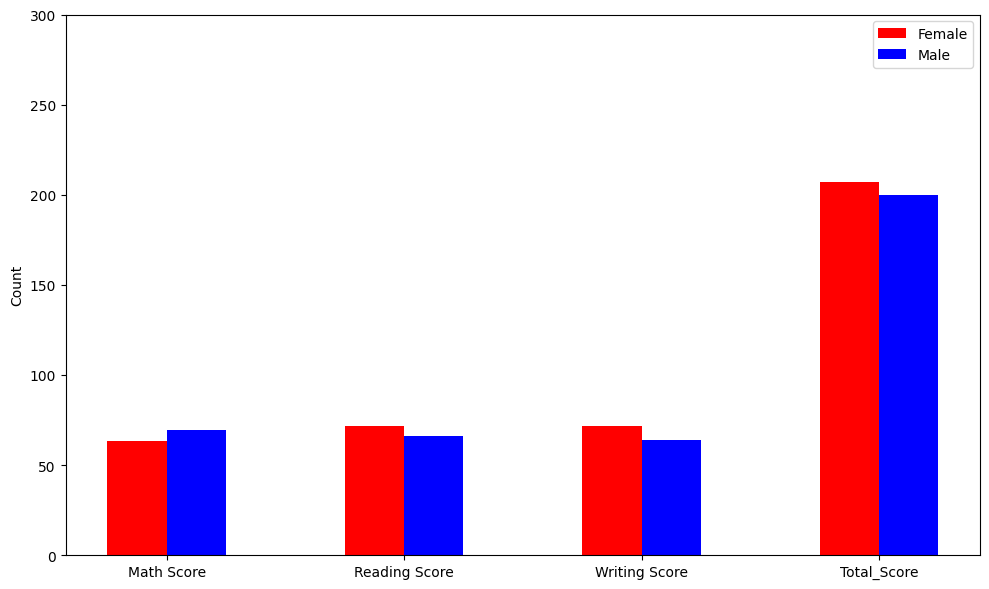

In [37]:
score_columns = ['math score', 'reading score', 'writing score', 'total_score']

mean_scores_by_gender = df.groupby('gender')[score_columns].mean()

female_scores = mean_scores_by_gender.loc['female']
male_scores = mean_scores_by_gender.loc['male']

x = np.arange(len(score_columns))
width = 0.25

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, female_scores, width, label='Female', color='red')
plt.bar(x + width/2, male_scores, width, label='Male', color='blue')


plt.xticks(ticks=x, labels=[col.title() for col in score_columns])
plt.ylim(0, 300)
plt.ylabel('Count')
plt.tight_layout()
plt.legend()
plt.show()

In genera, males perform better on math, while females perform better on everything else, including having a higher average test score

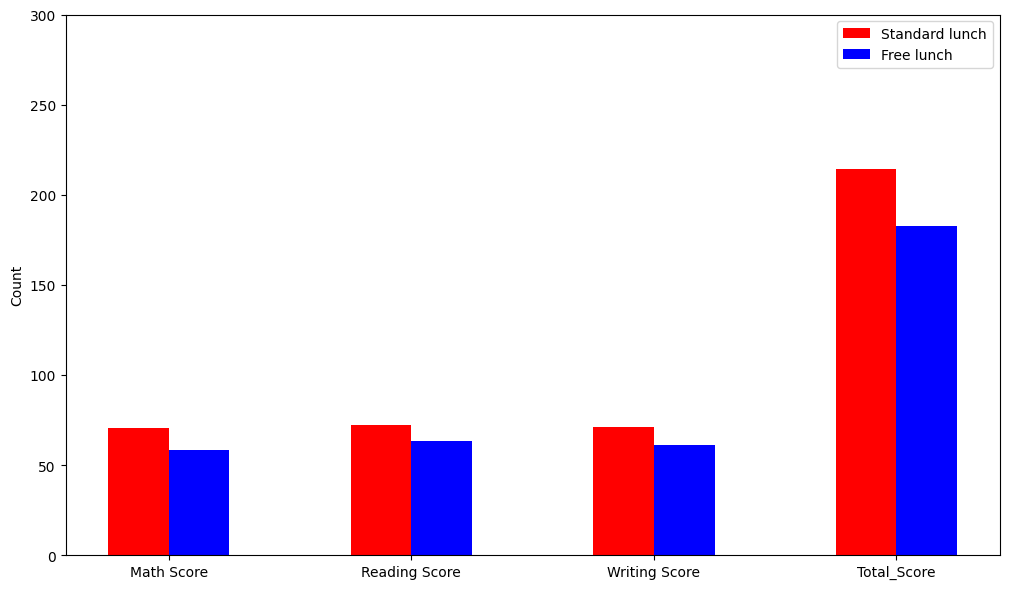

In [36]:
score_columns = ['math score', 'reading score', 'writing score', 'total_score']

mean_scores_by_lunch = df.groupby('lunch')[score_columns].mean()

standard_lunch = mean_scores_by_lunch.loc['standard']
free_lunch = mean_scores_by_lunch.loc['free/reduced']

x = np.arange(len(score_columns))
width = 0.25

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, standard_lunch, width, label='Standard lunch', color='red')
plt.bar(x + width/2, free_lunch, width, label='Free lunch', color='blue')


plt.xticks(ticks=x, labels=[col.title() for col in score_columns])
plt.ylim(0, 300)
plt.tight_layout()
plt.ylabel('Count')
plt.legend()
plt.show()


all students with a standard lunch perform much better than the students with the free lunch on average

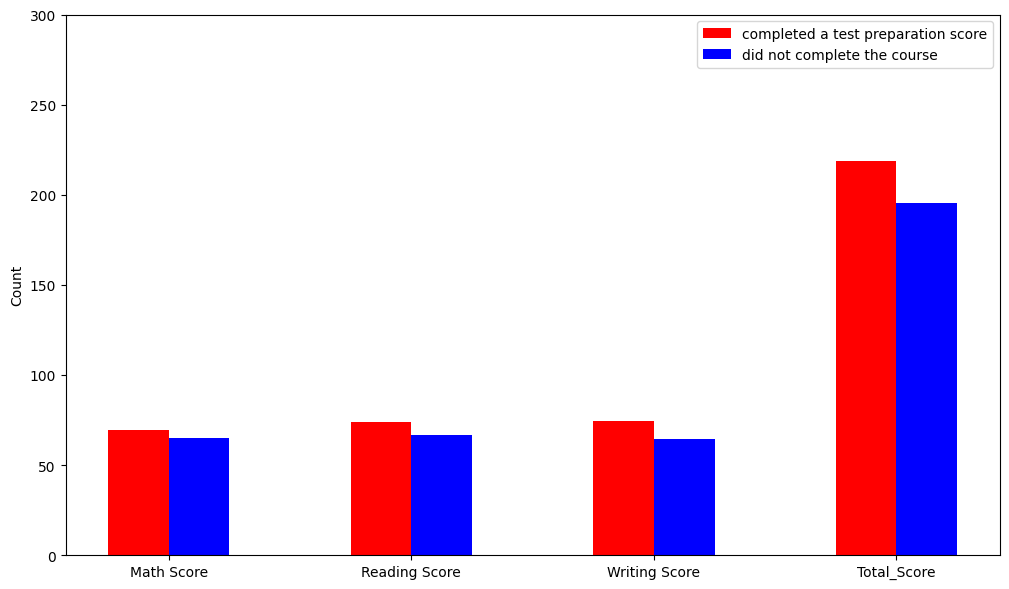

In [38]:
score_columns = ['math score', 'reading score', 'writing score', 'total_score']

mean_scores_by_test = df.groupby('test preparation course')[score_columns].mean()

completed = mean_scores_by_test.loc['completed']
not_completed = mean_scores_by_test.loc['none']

x = np.arange(len(score_columns))
width = 0.25

# Create the plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, completed, width, label='completed a test preparation score', color='red')
plt.bar(x + width/2, not_completed, width, label='did not complete the course', color='blue')


plt.xticks(ticks=x, labels=[col.title() for col in score_columns])
plt.ylim(0, 300)
plt.tight_layout()
plt.ylabel('Count')
plt.legend()
plt.show()

All students who completed a test preparation course outperformed the others.

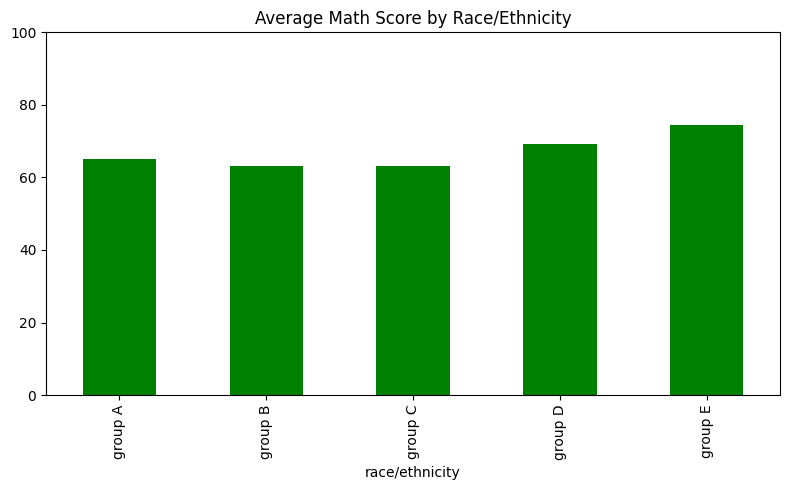

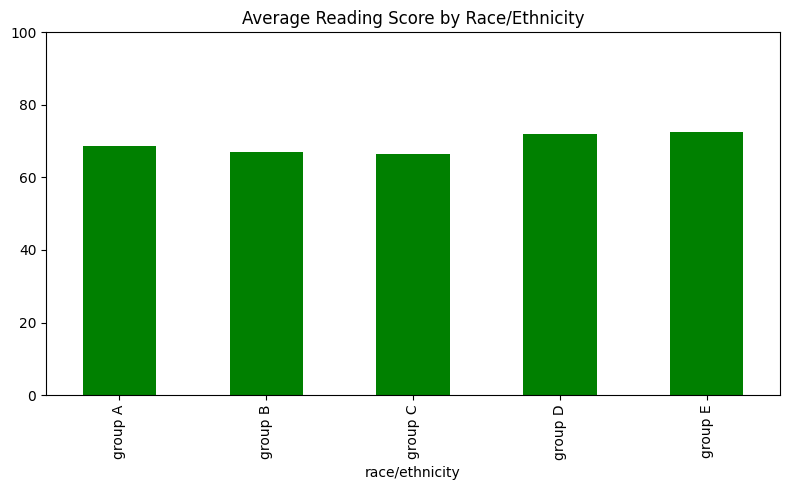

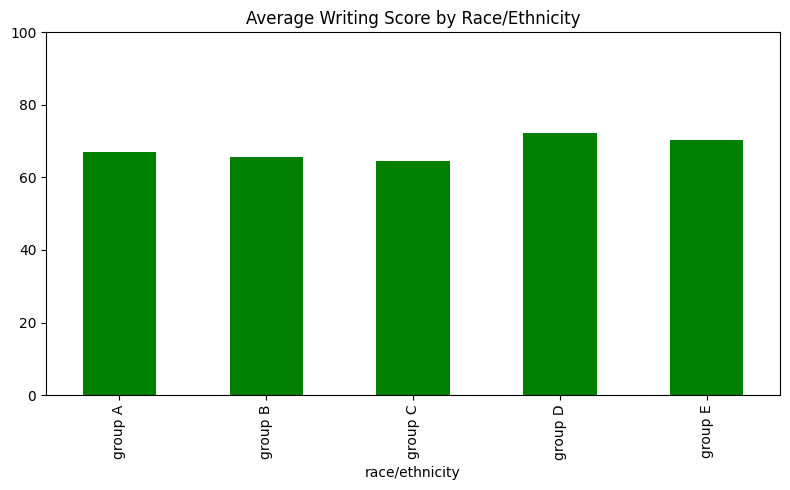

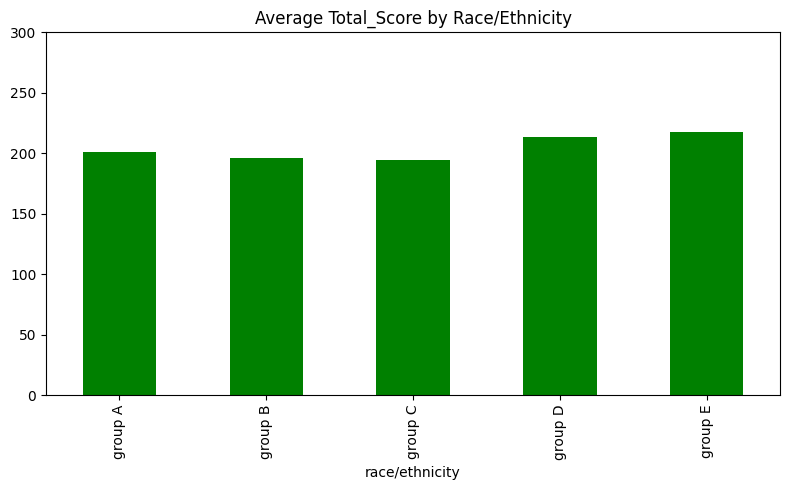

In [22]:
score_columns = ['math score', 'reading score', 'writing score', 'total_score']
ethnicity_groups = df['race/ethnicity'].unique()

for score in score_columns:
    mean_scores_by_ethnicity = df.groupby('race/ethnicity')[score].mean().sort_index()
    
    plt.figure(figsize=(8, 5))
    mean_scores_by_ethnicity.plot(kind='bar', color='green')
    
    plt.title(f'Average {score.title()} by Race/Ethnicity')
    if score != 'total_score':
        plt.ylim(0, 100)
    else:
        plt.ylim(0, 300)
    plt.tight_layout()
    plt.show()



Races D and E performed the best, but inconclusive